In [16]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

In [17]:
CHECKERBOARD = (7, 7)

In [18]:
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

In [19]:
objpoints = []
imgpoints = []

In [20]:
images = glob.glob("raw_captures/checkerboard/*.jpeg")

print("Number of images found:", len(images))

Number of images found: 14


In [21]:
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

successful_images = 0
failed_images = 0

for fname in images:

    img = cv2.imread(fname)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)

    if ret:

        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(
            gray,
            corners,
            (11,11),
            (-1,-1),
            criteria
        )

        imgpoints.append(corners2)

        successful_images += 1

    else:

        print("Corner detection failed:", fname)

        failed_images += 1

Corner detection failed: raw_captures/checkerboard\checker10.jpeg
Corner detection failed: raw_captures/checkerboard\checker11.jpeg
Corner detection failed: raw_captures/checkerboard\checker13.jpeg
Corner detection failed: raw_captures/checkerboard\checker2.jpeg
Corner detection failed: raw_captures/checkerboard\checker3.jpeg
Corner detection failed: raw_captures/checkerboard\checker5.jpeg
Corner detection failed: raw_captures/checkerboard\checker9.jpeg


In [22]:
print("Successful Images :", successful_images)
print("Failed Images :", failed_images)

Successful Images : 7
Failed Images : 7


In [23]:
ret, cameraMatrix, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    gray.shape[::-1],
    None,
    None
)

In [24]:
print(cameraMatrix)

[[3.77801461e+04 0.00000000e+00 8.06777831e+02]
 [0.00000000e+00 1.49051548e+04 4.50648359e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


In [25]:
fx = cameraMatrix[0,0]
fy = cameraMatrix[1,1]
cx = cameraMatrix[0,2]
cy = cameraMatrix[1,2]

print("Focal Length fx =", fx)
print("Focal Length fy =", fy)
print("Principal Point cx =", cx)
print("Principal Point cy =", cy)

Focal Length fx = 37780.14611455105
Focal Length fy = 14905.154775988518
Principal Point cx = 806.7778307330119
Principal Point cy = 450.6483591719757


In [26]:
print("Distortion Coefficients:")
print(dist)

Distortion Coefficients:
[[-1.71763584e+01 -5.72022965e+02  3.25018674e-01 -1.80995013e-02
  -8.30574927e-01]]


In [27]:
mean_error = 0

for i in range(len(objpoints)):

    imgpoints2, _ = cv2.projectPoints(
        objpoints[i],
        rvecs[i],
        tvecs[i],
        cameraMatrix,
        dist
    )

    error = cv2.norm(
        imgpoints[i],
        imgpoints2,
        cv2.NORM_L2
    ) / len(imgpoints2)

    mean_error += error

print("Overall Reprojection Error =", mean_error / len(objpoints))

Overall Reprojection Error = 1.3701622486268328


In [28]:
scene = cv2.imread("raw_captures/scene.jpeg")

In [29]:
undistorted = cv2.undistort(
    scene,
    cameraMatrix,
    dist
)

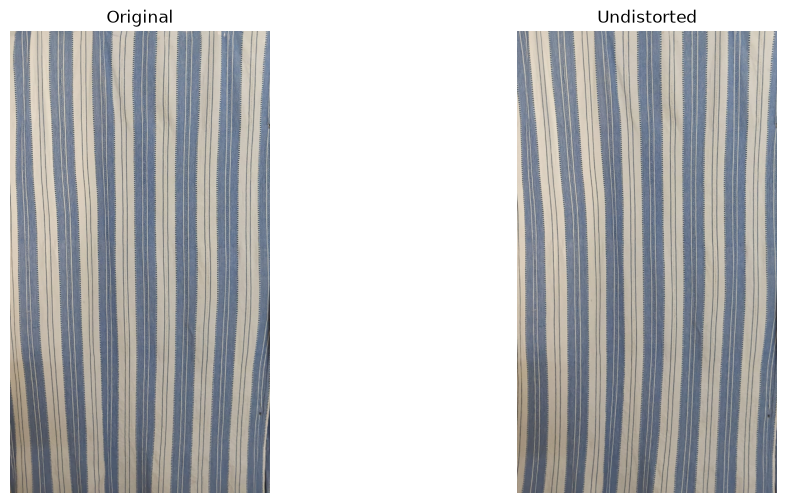

In [30]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.title("Undistorted")
plt.axis("off")

plt.show()

Observation

- Used 14 checkerboard images for calibration.
- Corner detection succeeded on 7 images.
- 7 images were discarded because they were blurry and had glare.
- The camera matrix and distortion coefficients were computed successfully.
- The scene image was undistorted using the calibration parameters.
- The straight lines near the image edges appeared slightly straighter after undistortion.